In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import datetime as dt

In [1]:


# To display plots inline in the notebook
%matplotlib inline

# Load your dataset
# For example, a CSV file
df = pd.read_csv('mockupdata (1).csv')



In [4]:
df.head()

,buyer_province,buyer_city,buyer_district,buyer_village,seller_province,seller_city,seller_district,seller_village,buyer_name,seller_name,...,normalized_item_name,brand,category,quantity,unit_amount,discount_amount,dpp_amount,ppn_amount,ppnbm_amount,gross_amount
0,Jawa Tengah,Solo,Banjarsari,Sragen,Jawa Tengah,Solo,Banjarsari,Sragen,Dinas Pekerjaan Umum,PT Rajasa Wacana (Persero) Tbk,...,edible vegetable oil,barco,Edible vegetable or plant oils,8,2446987,555493,19020403,2092244,0,21112647
1,Jawa Barat,Bandung,Coblong,Dago,Jawa Tengah,Solo,Banjarsari,Sragen,Kementerian Pendidikan,Perum Pangestu (Persero) Tbk,...,soft drinks,lasegar,Soft drinks,7,6452509,3926287,41241276,4536540,0,45777816
2,Jawa Tengah,Solo,Banjarsari,Sragen,Jawa Tengah,Solo,Banjarsari,Sragen,Dinas Perhubungan,Perum Widiastuti Tbk,...,powdered milk,nutrilon,Powdered milk,6,2760343,1131159,15430899,1697398,0,17128297
3,Bali,Badung,Kuta,Legian,DKI Jakarta,Jakarta Barat,Grogol,Tanjung Duren,Dinas Pendidikan,PT Salahudin Winarno (Persero) Tbk,...,detergent and laundry products,vanish,Laundry products,8,9274173,1385185,72808199,8008901,0,80817100
4,Bali,Badung,Kuta,Legian,Jawa Tengah,Solo,Banjarsari,Sragen,Sekretariat Perhubungan,PT Pradana Hakim,...,snack foods,wafello,Snack foods,10,3744634,30160,37416180,4115779,0,41531959


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   buyer_province                  1000 non-null   object
 1   buyer_city                      1000 non-null   object
 2   buyer_district                  1000 non-null   object
 3   buyer_village                   1000 non-null   object
 4   seller_province                 1000 non-null   object
 5   seller_city                     1000 non-null   object
 6   seller_district                 1000 non-null   object
 7   seller_village                  1000 non-null   object
 8   buyer_name                      1000 non-null   object
 9   seller_name                     1000 non-null   object
 10  buyer_npwp                      1000 non-null   int64 
 11  buyer_active_pkp_flag           1000 non-null   bool  
 12  seller_npwp                     1000 non-null   i

In [7]:
df.describe()

,buyer_npwp,seller_npwp,buyer_klu_code,seller_klu_code,quantity,unit_amount,discount_amount,dpp_amount,ppn_amount,ppnbm_amount,gross_amount
count,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.0,1.000000e+03
mean,5.524873e+14,5.621429e+14,34498.348000,34498.348000,5.612000,4.901701e+06,1.349605e+06,2.665653e+07,2.932218e+06,0.0,2.958875e+07
std,2.617208e+14,2.617349e+14,25815.896648,25815.896648,2.855803,2.912588e+06,1.568524e+06,2.290838e+07,2.519922e+06,0.0,2.542830e+07
min,1.005962e+14,1.002786e+14,1123.000000,1123.000000,1.000000,5.357500e+04,1.469000e+03,9.019300e+04,9.921000e+03,0.0,1.001140e+05
25%,3.246271e+14,3.410177e+14,10802.000000,10802.000000,3.000000,2.347950e+06,2.553450e+05,7.933824e+06,8.727202e+05,0.0,8.806544e+06
50%,5.567490e+14,5.728625e+14,28222.000000,28222.000000,6.000000,4.891228e+06,7.728745e+05,1.925422e+07,2.117964e+06,0.0,2.137219e+07
75%,7.761603e+14,7.820363e+14,50228.000000,50228.000000,8.000000,7.366228e+06,1.735714e+06,4.047610e+07,4.452371e+06,0.0,4.492847e+07
max,9.990412e+14,9.981298e+14,92429.000000,92429.000000,10.000000,9.987944e+06,9.059920e+06,9.717614e+07,1.068938e+07,0.0,1.078655e+08


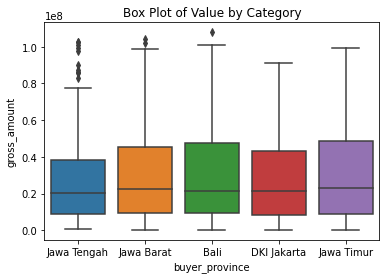

In [15]:
sns.boxplot(data=df,x='buyer_province', y='gross_amount')
plt.title('Box Plot of Value by Category')
plt.show()


In [23]:
# Pivot with margins
pivot1 = pd.pivot_table(
    df,
    values='gross_amount',
    index='category',
    columns='buyer_province',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)
pivot1_sort = pivot1.sort_values(by='Total', ascending=False)
pivot1_sort.head()

buyer_province,Bali,DKI Jakarta,Jawa Barat,Jawa Tengah,Jawa Timur,Total
category,,,,,,
Customer relationship management software maintenance,5.305596e+07,4.803699e+07,38310296.0,3.339218e+07,1.302019e+07,4.042773e+07
Soft drinks,4.000833e+07,3.416757e+07,39660876.0,2.786797e+07,4.783615e+07,3.779872e+07
Tablet computers,3.489271e+07,1.316103e+06,8506527.0,5.188600e+07,4.598175e+07,3.778971e+07
Diesel generators,5.663060e+07,2.942843e+07,36598876.0,2.210808e+07,NaN,3.530456e+07
Hot water dispenser,NaN,NaN,69942803.0,2.157060e+07,3.718255e+07,3.483662e+07


In [27]:
# Pivot with margins
pivot1 = pd.pivot_table(
    df,
    values='unit_amount',
    index='category',
    columns='buyer_province',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)
pivot1_sort = pivot1.sort_values(by='Total', ascending=False)
pivot1_sort.head()

buyer_province,Bali,DKI Jakarta,Jawa Barat,Jawa Tengah,Jawa Timur,Total
category,,,,,,
Hot water dispenser,NaN,NaN,8709648.0,4.676578e+06,6.149097e+06,5.839596e+06
Soft drinks,6.360255e+06,4.961992e+06,5660945.0,3.741736e+06,6.818862e+06,5.513679e+06
Feminine hygiene products,6.239021e+06,5.844636e+06,3293714.5,5.620600e+06,5.577288e+06,5.454267e+06
Tablet computers,7.167167e+06,1.236125e+06,1955196.0,5.180936e+06,5.467100e+06,5.358890e+06
Customer relationship management software maintenance,6.954016e+06,5.008404e+06,4488472.5,4.394522e+06,4.161497e+06,5.305827e+06


In [29]:
# Pivot with margins
pivot1 = pd.pivot_table(
    df,
    values='quantity',
    index='category',
    columns='buyer_province',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)
pivot1_sort = pivot1.sort_values(by='Total', ascending=False)
pivot1_sort.head()

buyer_province,Bali,DKI Jakarta,Jawa Barat,Jawa Tengah,Jawa Timur,Total
category,,,,,,
Customer relationship management software maintenance,6.714286,8.500000,7.500000,7.750000,4.666667,7.090909
Diesel generators,7.000000,5.875000,6.000000,7.000000,NaN,6.375000
Insurance law service,5.846154,5.750000,7.200000,6.333333,7.250000,6.350000
Online and social media publicity service,7.000000,6.428571,7.666667,3.000000,4.333333,6.263158
Tablet computers,5.250000,1.000000,4.000000,5.500000,8.166667,6.142857


In [30]:
# Pivot with margins
pivot1 = pd.pivot_table(
    df,
    values='quantity',
    index='category',
    columns='buyer_province',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)
pivot1_sort = pivot1.sort_values(by='Total', ascending=False)
pivot1_sort.head()

buyer_province,Bali,DKI Jakarta,Jawa Barat,Jawa Tengah,Jawa Timur,Total
category,,,,,,
Total,1140.0,1196.0,1131.0,1040.0,1105.0,5612
Water,52.0,116.0,82.0,61.0,31.0,342
Snack foods,109.0,81.0,45.0,49.0,58.0,342
Domestic refrigerators,60.0,65.0,73.0,43.0,68.0,309
Laundry products,47.0,47.0,69.0,68.0,76.0,307


In [38]:
# Pivot with margins
pivot2 = pd.pivot_table(
    df,
    values='quantity',
    index='category',
#     columns='buyer_province',
    aggfunc='sum',
#     margins=True,
#     margins_name='Total'
)
pivot2
pivot2sort = pivot2.sort_values(by='quantity', ascending=False)
pivot2sort.head()

,quantity
category,
Water,342
Snack foods,342
Domestic refrigerators,309
Laundry products,307
Facial care products,277


In [39]:
# Pivot with margins
pivot2 = pd.pivot_table(
    df,
    values='ppn_amount',
    index='category',
#     columns='buyer_province',
    aggfunc='sum',
#     margins=True,
#     margins_name='Total'
)
pivot2
pivot2sort = pivot2.sort_values(by='ppn_amount', ascending=False)
pivot2sort.head()

,ppn_amount
category,
Snack foods,198391488
Water,191617877
Laundry products,167444618
Feminine hygiene products,146662048
Domestic refrigerators,145930284


In [42]:
# Pivot with margins
pivot2 = pd.pivot_table(
    df,
    values='quantity',
    index='seller_name',
#     columns='buyer_province',
    aggfunc='sum',
#     margins=True,
#     margins_name='Total'
)
pivot2
pivot2sort = pivot2.sort_values(by='quantity', ascending=False)
pivot2sort.head()

,quantity
seller_name,
CV Haryanti,20
PD Nainggolan (Persero) Tbk,19
PD Utama (Persero) Tbk,19
CV Simanjuntak Tbk,18
PT Jailani,18


In [44]:
# Pivot with margins
pivot2 = pd.pivot_table(
    df,
    values='ppn_amount',
    index='seller_name',
#     columns='buyer_province',
    aggfunc='sum',
#     margins=True,
#     margins_name='Total'
)
pivot2
pivot2sort = pivot2.sort_values(by='ppn_amount', ascending=False)
pivot2sort.head()

,ppn_amount
seller_name,
CV Suwarno,17019755
PT Jailani,16323572
UD Fujiati,14522479
Perum Mayasari,13863156
CV Siregar,12189828


In [28]:
# Pivot with margins
pivot1 = pd.pivot_table(
    df,
    values='gross_amount',
    index='brand',
    columns='buyer_province',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)
pivot1_sort = pivot1.sort_values(by='Total', ascending=False)
pivot1_sort.head()

buyer_province,Bali,DKI Jakarta,Jawa Barat,Jawa Tengah,Jawa Timur,Total
brand,,,,,,
denpoo,6.881587e+07,9869969.0,68650912.0,NaN,3.247197e+07,4.969193e+07
lovol,9.160215e+07,39438072.5,NaN,25629909.50,NaN,4.902705e+07
laureir,4.138758e+07,45898272.5,50492422.0,55859889.00,1.631565e+07,4.053519e+07
salesforce,5.305596e+07,48036986.0,38310296.0,33392178.75,1.302019e+07,4.042773e+07
daikin,2.294934e+07,58482731.2,63715822.0,24657546.50,1.874865e+07,3.989700e+07


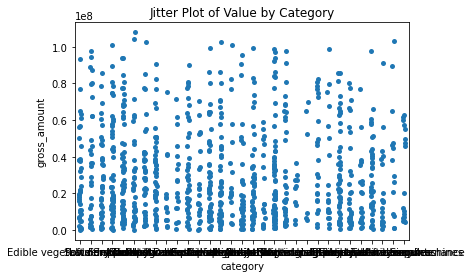

In [24]:
# Create a jitter plot
sns.stripplot(data=df, x='category', y='gross_amount', jitter=True)
plt.title('Jitter Plot of Value by Category')
plt.show()

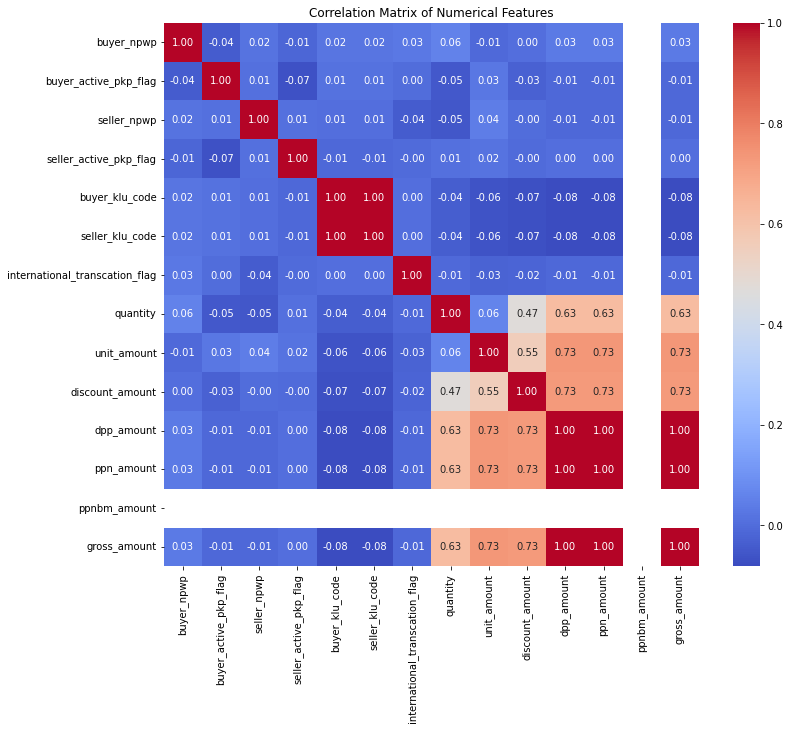

In [26]:
corr_matrix = df.corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [45]:
sumps = df.groupby('seller_name')['quantity'].sum()
sumps = sumps.reset_index()
sumps.head()

,seller_name,quantity
0,CV Adriansyah Rahimah (Persero) Tbk,3
1,CV Agustina Tbk,4
2,CV Andriani Irawan (Persero) Tbk,4
3,CV Andriani Palastri,7
4,CV Anggraini Pertiwi (Persero) Tbk,9


In [48]:
sumps = df.groupby('seller_name')['quantity','unit_amount','dpp_amount','ppn_amount'].sum()
sumps = sumps.reset_index()
sumps.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3224\688511208.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sumps = df.groupby('seller_name')['quantity','unit_amount','dpp_amount','ppn_amount'].sum()


,seller_name,quantity,unit_amount,dpp_amount,ppn_amount
0,CV Adriansyah Rahimah (Persero) Tbk,3,1347834,3728430,410127
1,CV Agustina Tbk,4,9826741,37245611,4097017
2,CV Andriani Irawan (Persero) Tbk,4,8586665,34335887,3776947
3,CV Andriani Palastri,7,2984217,19723893,2169628
4,CV Anggraini Pertiwi (Persero) Tbk,9,8249476,69668554,7663540


In [50]:
# Rescaling Atribute
sumps_re = sumps[['quantity', 'unit_amount', 'dpp_amount','ppn_amount']]
# Instantiate
scaler = StandardScaler()
# fit_transform
sum_resc = scaler.fit_transform(sumps_re)
sum_resc.shape

(951, 4)

In [51]:
sum_resc = pd.DataFrame(sum_resc)
sum_resc.columns = ['quantity', 'unit_amount', 'dpp_amount','ppn_amount']
sum_resc.head()

,quantity,unit_amount,dpp_amount,ppn_amount
0,-0.886082,-1.165262,-0.971259,-0.971259
1,-0.580658,1.430389,0.368320,0.368320
2,-0.580658,1.050764,0.252027,0.252027
3,0.335613,-0.664316,-0.331970,-0.331970
4,0.946460,0.947540,1.664165,1.664165


In [52]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(sum_resc)

KMeans(max_iter=50, n_clusters=4)

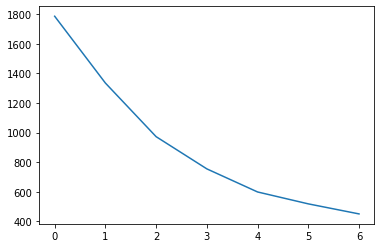

In [53]:
# Elbow-curve/SSD
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(sum_resc)
    
    ssd.append(kmeans.inertia_)
    
# plot the SSDs for each n_clusters
plt.plot(ssd)

In [56]:
# Silhouette Analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    
    # Initialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(sum_resc)
    cluster_labels = kmeans.labels_
    
    # Silhouette Score
    silhouette_avg = silhouette_score(sum_resc, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))


For n_clusters=2, the silhouette score is 0.48529464196635597
For n_clusters=3, the silhouette score is 0.3601372157207455
For n_clusters=4, the silhouette score is 0.3795417583798531
For n_clusters=5, the silhouette score is 0.3906343105590749
For n_clusters=6, the silhouette score is 0.38769628218881624
For n_clusters=7, the silhouette score is 0.37879768765157257
For n_clusters=8, the silhouette score is 0.3676384254654079


In [57]:
# Final model with k=2
kmeans = KMeans(n_clusters=2, max_iter=50)
kmeans.fit(sum_resc)

KMeans(max_iter=50, n_clusters=2)

In [58]:
# Assign the label
sumps['Cluster_Id'] = kmeans.labels_
sumps.head()

,seller_name,quantity,unit_amount,dpp_amount,ppn_amount,Cluster_Id
0,CV Adriansyah Rahimah (Persero) Tbk,3,1347834,3728430,410127,0
1,CV Agustina Tbk,4,9826741,37245611,4097017,1
2,CV Andriani Irawan (Persero) Tbk,4,8586665,34335887,3776947,0
3,CV Andriani Palastri,7,2984217,19723893,2169628,0
4,CV Anggraini Pertiwi (Persero) Tbk,9,8249476,69668554,7663540,1


In [71]:
sumps.groupby('Cluster_Id')['seller_name'].count()


Cluster_Id
0    663
1    288
Name: seller_name, dtype: int64

<AxesSubplot: xlabel='Cluster_Id', ylabel='ppn_amount'>

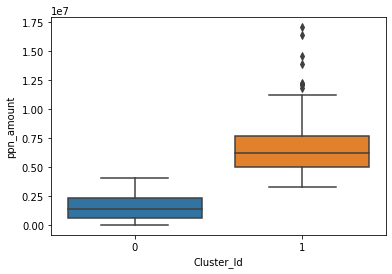

In [59]:
sns.boxplot(x='Cluster_Id', y='ppn_amount', data=sumps)


<AxesSubplot: xlabel='Cluster_Id', ylabel='dpp_amount'>

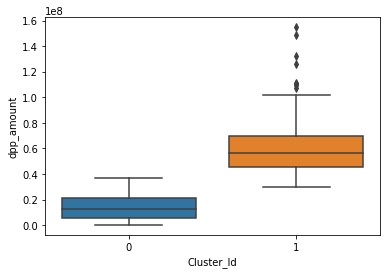

In [60]:
sns.boxplot(x='Cluster_Id', y='dpp_amount', data=sumps)

<AxesSubplot: xlabel='Cluster_Id', ylabel='quantity'>

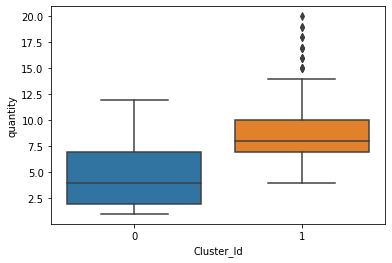

In [61]:
sns.boxplot(x='Cluster_Id', y='quantity', data=sumps)

<AxesSubplot: xlabel='Cluster_Id', ylabel='unit_amount'>

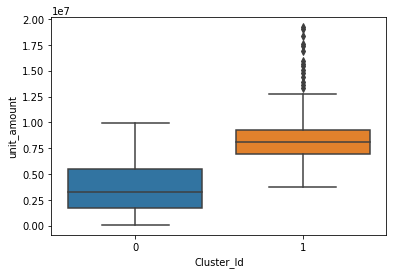

In [62]:
sns.boxplot(x='Cluster_Id', y='unit_amount', data=sumps)

In [73]:
sorted_seller = sumps.sort_values(by='ppn_amount',ascending=False)
sorted_seller.head()

,seller_name,quantity,unit_amount,dpp_amount,ppn_amount,Cluster_Id
157,CV Suwarno,17,19203100,154725060,17019755,1
420,PT Jailani,18,17413368,148396121,16323572,1
774,UD Fujiati,17,16871737,132022538,14522479,1
636,Perum Mayasari,17,15070041,126028700,13863156,1
142,CV Siregar,16,13313101,110816627,12189828,1


In [63]:
sumps2 = df.groupby('category')['quantity','unit_amount','dpp_amount','ppn_amount'].sum()
sumps2 = sumps2.reset_index()
sumps2.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3224\3214666067.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sumps2 = df.groupby('category')['quantity','unit_amount','dpp_amount','ppn_amount'].sum()


,category,quantity,unit_amount,dpp_amount,ppn_amount
0,Accounting software,54,42468553,186327885,20496063
1,Advertising,234,220002127,1119667357,123163386
2,Air conditioners,223,184573214,1072494387,117974362
3,Customer relationship management software main...,156,116728196,801270422,88139736
4,Diesel generators,102,82157941,508894583,55978396


In [64]:
# Rescaling Atribute
sumps_re = sumps2[['quantity', 'unit_amount', 'dpp_amount','ppn_amount']]
# Instantiate
scaler = StandardScaler()
# fit_transform
sum_resc = scaler.fit_transform(sumps_re)
sum_resc.shape

(31, 4)

In [65]:
sum_resc = pd.DataFrame(sum_resc)
sum_resc.columns = ['quantity', 'unit_amount', 'dpp_amount','ppn_amount']
sum_resc.head()

,quantity,unit_amount,dpp_amount,ppn_amount
0,-1.481198,-1.413818,-1.517994,-1.517994
1,0.617605,0.756510,0.585461,0.585461
2,0.489345,0.323395,0.479148,0.479148
3,-0.291877,-0.506002,-0.132106,-0.132106
4,-0.921517,-0.928620,-0.791030,-0.791030


In [66]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(sum_resc)

KMeans(max_iter=50, n_clusters=4)

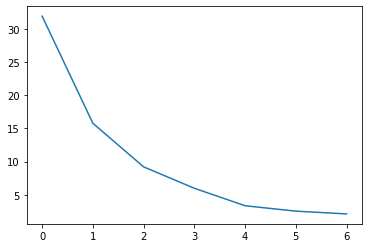

In [67]:
# Elbow-curve/SSD
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(sum_resc)
    
    ssd.append(kmeans.inertia_)
    
# plot the SSDs for each n_clusters
plt.plot(ssd)

In [68]:
# Silhouette Analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    
    # Initialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(sum_resc)
    cluster_labels = kmeans.labels_
    
    # Silhouette Score
    silhouette_avg = silhouette_score(sum_resc, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))


For n_clusters=2, the silhouette score is 0.6317404179064668
For n_clusters=3, the silhouette score is 0.5656390655191426
For n_clusters=4, the silhouette score is 0.5847508114912415
For n_clusters=5, the silhouette score is 0.5702677735919687
For n_clusters=6, the silhouette score is 0.5948657561807236
For n_clusters=7, the silhouette score is 0.5587758066746297
For n_clusters=8, the silhouette score is 0.5520217794345718


In [69]:
# Final model with k=2
kmeans = KMeans(n_clusters=2, max_iter=50)
kmeans.fit(sum_resc)

KMeans(max_iter=50, n_clusters=2)

In [70]:
# Assign the label
sumps2['Cluster_Id'] = kmeans.labels_
sumps2.head()

,category,quantity,unit_amount,dpp_amount,ppn_amount,Cluster_Id
0,Accounting software,54,42468553,186327885,20496063,1
1,Advertising,234,220002127,1119667357,123163386,0
2,Air conditioners,223,184573214,1072494387,117974362,0
3,Customer relationship management software main...,156,116728196,801270422,88139736,1
4,Diesel generators,102,82157941,508894583,55978396,1


In [75]:
sumps2.groupby('Cluster_Id')['category'].count()

Cluster_Id
0    16
1    15
Name: category, dtype: int64

<AxesSubplot: xlabel='Cluster_Id', ylabel='ppn_amount'>

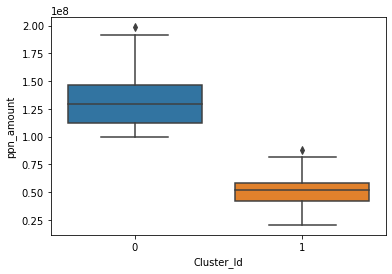

In [76]:
sns.boxplot(x='Cluster_Id', y='ppn_amount', data=sumps2)


<AxesSubplot: xlabel='Cluster_Id', ylabel='dpp_amount'>

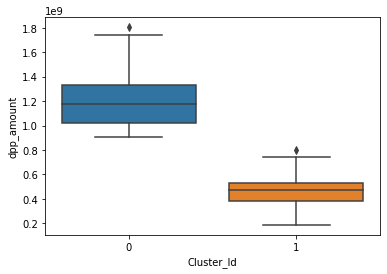

In [77]:
sns.boxplot(x='Cluster_Id', y='dpp_amount', data=sumps2)

<AxesSubplot: xlabel='Cluster_Id', ylabel='unit_amount'>

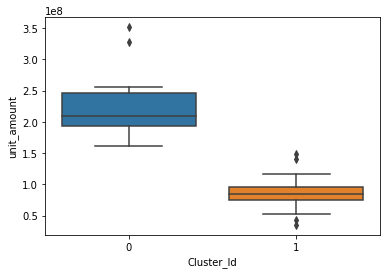

In [78]:
sns.boxplot(x='Cluster_Id', y='unit_amount', data=sumps2)

<AxesSubplot: xlabel='Cluster_Id', ylabel='quantity'>

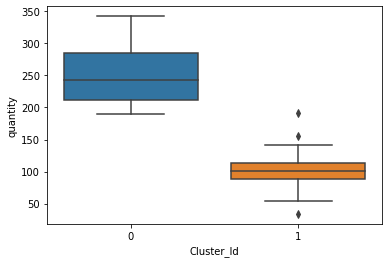

In [79]:
sns.boxplot(x='Cluster_Id', y='quantity', data=sumps2)

In [80]:
sorted_cat = sumps2.sort_values(by='ppn_amount',ascending=False)
sorted_cat.head()

,category,quantity,unit_amount,dpp_amount,ppn_amount,Cluster_Id
23,Snack foods,342,328410139,1803559250,198391488,0
30,Water,342,351341037,1741981044,191617877,0
15,Laundry products,307,253088995,1522224051,167444618,0
9,Feminine hygiene products,260,256350538,1333291553,146662048,0
6,Domestic refrigerators,309,244874905,1326639190,145930284,0
